In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving 1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv to 1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv


In [5]:
import pandas as pd

df = pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [7]:
df.shape

(301, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [11]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [12]:
df['Car_Age'] = 2026 - df['Year']


In [13]:
df['Car_Age'] = 2026 - df['Year']


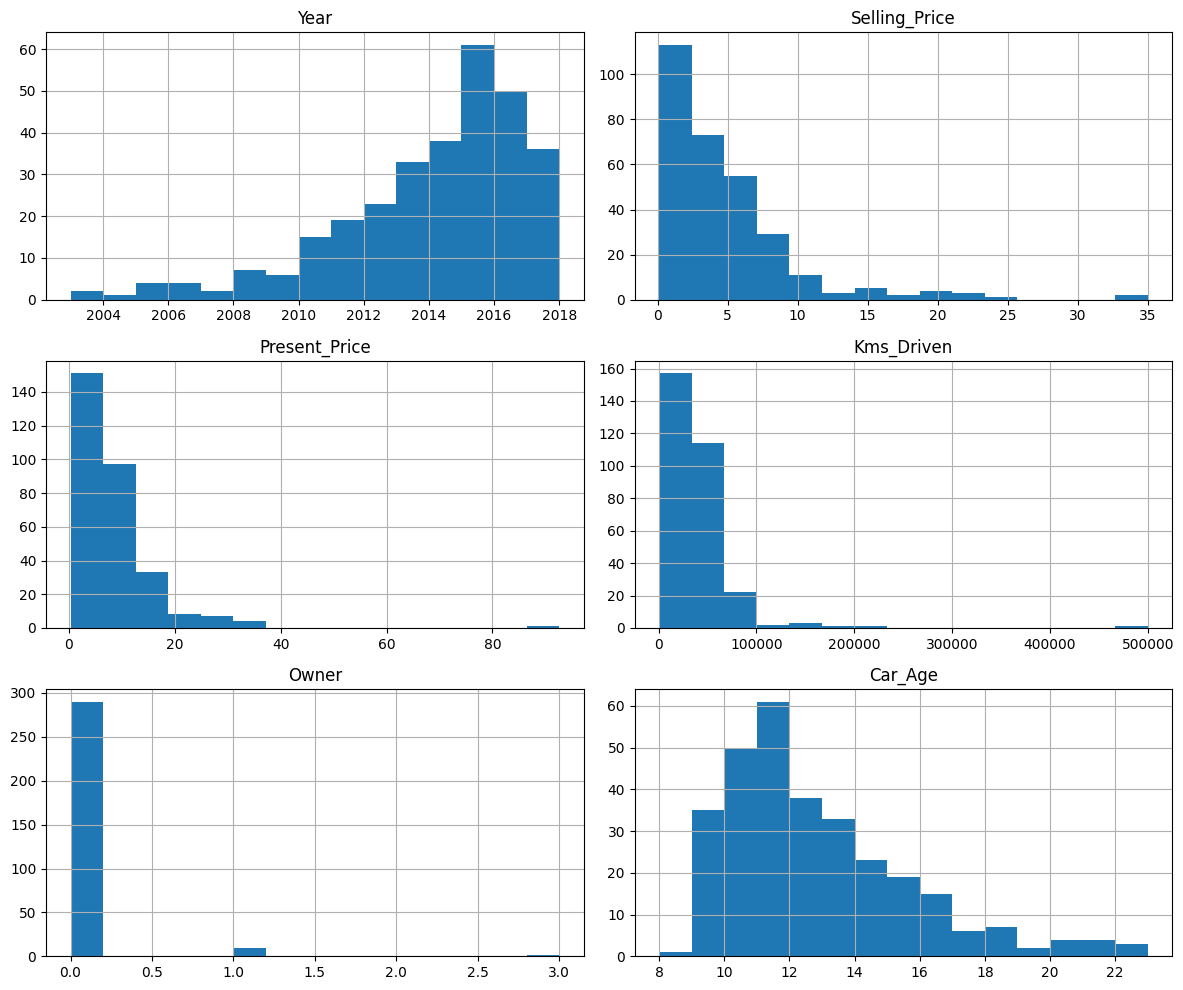

In [14]:
df.hist(bins=15, figsize=(12, 10))
plt.tight_layout()
plt.savefig("01_histograms.png", dpi=120)
plt.show()
plt.close()

In [15]:
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age']

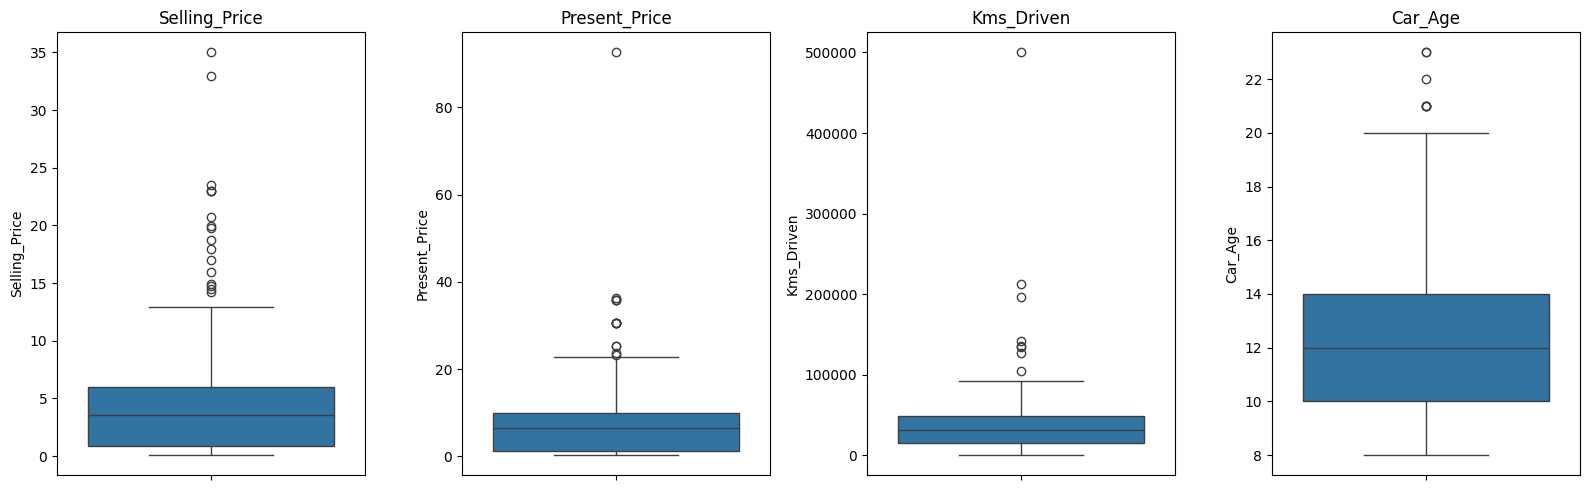

In [16]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("02_boxplots_before.png", dpi=120)
plt.show()
plt.close()

In [17]:
def remove_outliers(col_name):
    sorted(col_name)
    Q1, Q3 = col_name.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return lower_range, upper_range

In [18]:
low, high = remove_outliers(df['Kms_Driven'])
df['Kms_Driven'] = np.where(df['Kms_Driven'] > high, high,
                     np.where(df['Kms_Driven'] < low, low, df['Kms_Driven']))

In [19]:
low, high = remove_outliers(df['Selling_Price'])
df['Selling_Price'] = np.where(df['Selling_Price'] > high, high,
                        np.where(df['Selling_Price'] < low, low, df['Selling_Price']))

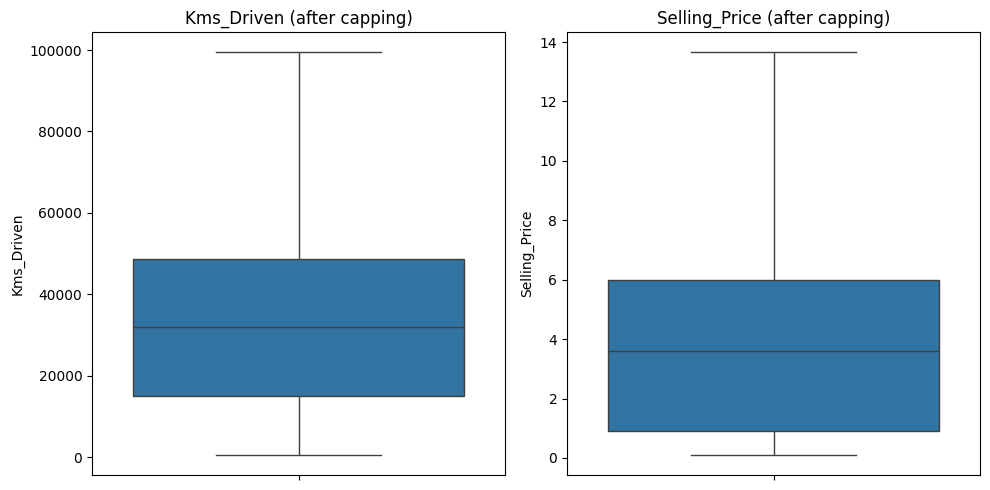

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(y='Kms_Driven', data=df, ax=axes[0])
axes[0].set_title('Kms_Driven (after capping)')
sns.boxplot(y='Selling_Price', data=df, ax=axes[1])
axes[1].set_title('Selling_Price (after capping)')
plt.tight_layout()
plt.savefig("03_boxplots_after.png", dpi=120)
plt.show()
plt.close()

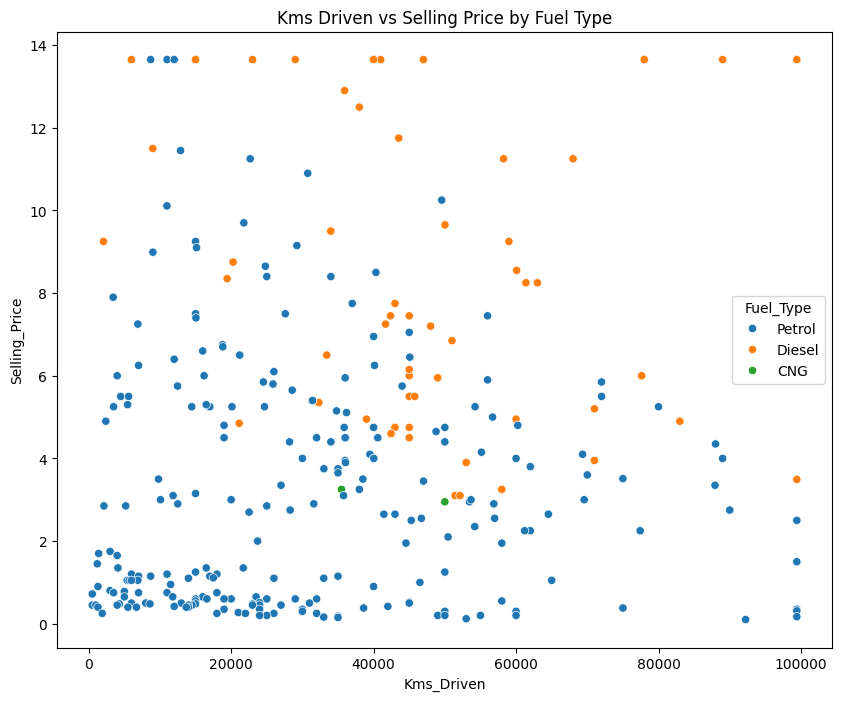

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, hue='Fuel_Type')
plt.title("Kms Driven vs Selling Price by Fuel Type")
plt.savefig("04_scatter_kms_vs_price.png", dpi=120)
plt.show()
plt.close()

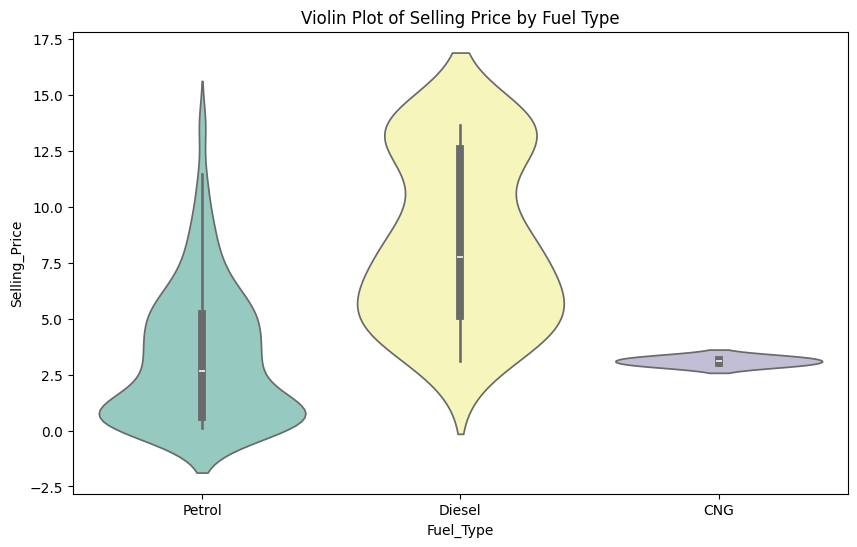

In [23]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", data=df, palette="Set3", legend=False)
plt.title("Violin Plot of Selling Price by Fuel Type")
plt.savefig("05_violin_price_by_fuel.png", dpi=120)
plt.show()
plt.close()

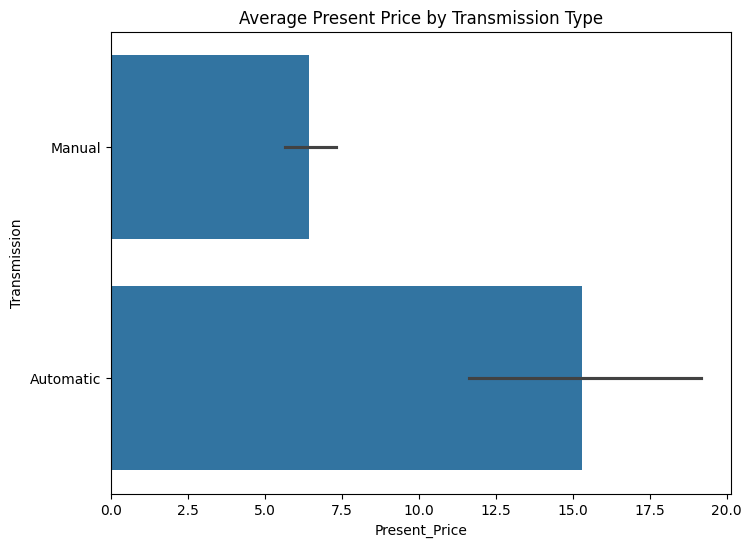

In [24]:
plt.figure(figsize=(8, 6))
sns.barplot(y='Transmission', x='Present_Price', data=df)
plt.title("Average Present Price by Transmission Type")
plt.savefig("06_bar_price_by_transmission.png", dpi=120)
plt.show()
plt.close()

In [25]:
avg_price_by_seller = df.groupby(['Seller_Type'])['Selling_Price'].mean().sort_values(ascending=False)
print(avg_price_by_seller)

Seller_Type
Dealer        6.133385
Individual    0.848774
Name: Selling_Price, dtype: float64


In [26]:
avg_price_by_fuel = df.groupby(['Fuel_Type'])['Selling_Price'].mean().sort_values(ascending=False)
print(avg_price_by_fuel)

Fuel_Type
Diesel    8.494833
Petrol    3.222134
CNG       3.100000
Name: Selling_Price, dtype: float64


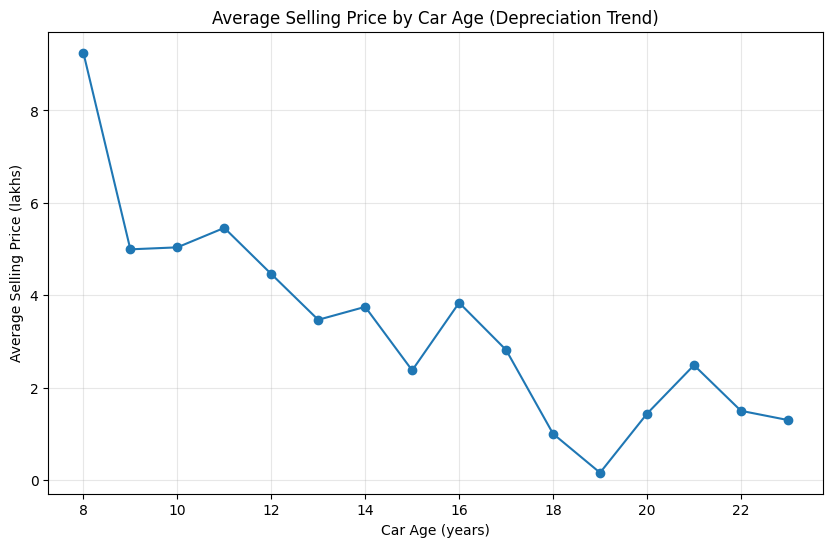

In [27]:
depreciation_by_age = df.groupby('Car_Age')['Selling_Price'].mean().sort_index()
plt.figure(figsize=(10, 6))
depreciation_by_age.plot(kind='line', marker='o')
plt.title("Average Selling Price by Car Age (Depreciation Trend)")
plt.xlabel("Car Age (years)")
plt.ylabel("Average Selling Price (lakhs)")
plt.grid(True, alpha=0.3)
plt.savefig("07_depreciation_trend.png", dpi=120)
plt.show()
plt.close()

In [28]:
print("Analysis complete. Plots saved as PNG files in the working directory.")

Analysis complete. Plots saved as PNG files in the working directory.
